# Autoencoder Training

This notebook trains a convolutional autoencoder on **normal data** (no chatter).  
The model learns a compact representation and attempts to reconstruct the input images.  
Because anomalous samples (chatter) are not seen during training, we expect them to yield a **higher reconstruction error**.

**Core idea:** anomaly score = reconstruction error (e.g., MSE) between the input and its reconstruction.

In [1]:
import os
import random
import numpy as np
import pandas as pd
import tensorflow as tf
from PIL import Image
from tqdm import tqdm
import plotly.express as px 
import os
from pathlib import Path
from collections import defaultdict

from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, UpSampling2D
from tensorflow.keras.layers import Dense, Flatten, Reshape
import matplotlib.pyplot as plt
from tensorflow.keras.callbacks import EarlyStopping

In [2]:
# =========================
# Reproducibility (Seeds)
# =========================
SEED = 42

os.environ["PYTHONHASHSEED"] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

# =========================
# GPU check (optional)
# =========================
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    print(f"TensorFlow detects {len(gpus)} GPU(s):")
    for gpu in gpus:
        print("-", gpu)
else:
    print("No GPU found.")

No GPU found.


## Data

The spectrograms are loaded as images.

We distinguish between:
- **GOOD / Normal**: samples without chatter (used for training)
- **BAD / Chatter**: potentially anomalous samples (typically used for evaluation)

This notebook trains the autoencoder using **only the normal (GOOD)** class.

In [3]:
def extract_file_id(path):
    return Path(path).stem.split("_seg")[0]

In [4]:
TEST_SIZE = 0.2 # percentage
VAL_SIZE = 0.3   # percent
MIN_FILES = 5    # Min. files for splitting

DATA_ROOT = Path("../../data/04_bosch_dataset/M01/OP12") #only Machine 1 samples

# Collect all GOOD / BADimages
GOOD_PATHS = list((DATA_ROOT / "good").rglob("*.png"))
BAD_PATHS = list((DATA_ROOT / "bad").rglob("*.png"))

file_to_paths = defaultdict(list)

for p in GOOD_PATHS:
    fid = extract_file_id(p)
    file_to_paths[fid].append(p)

# Good-File splitting

file_ids = list(file_to_paths.keys())
n_files = len(file_ids)

if n_files < MIN_FILES:
    raise ValueError(f"Zu wenige GOOD-Dateien: {n_files}")

# Erst Train vs Temp (Val+Test)
train_files, temp_files = train_test_split(
    file_ids,
    test_size=TEST_SIZE + VAL_SIZE,
    random_state=SEED,
    shuffle=True
)

# Anteil Test relativ zu temp berechnen
relative_test_size = TEST_SIZE / (TEST_SIZE + VAL_SIZE)

val_files, test_files = train_test_split(
    temp_files,
    test_size=relative_test_size,
    random_state=SEED,
    shuffle=True
)

print(f"GOOD split -> Train: {len(train_files)}, Val: {len(val_files)}, Test: {len(test_files)}")
#-------------------------------------


# bad files
bad_file_to_paths = defaultdict(list)

for p in BAD_PATHS:
    fid = extract_file_id(p)
    bad_file_to_paths[fid].append(p)



bad_file_ids = list(bad_file_to_paths.keys())
n_bad = len(bad_file_ids)

if n_bad < 3:
    print(f"Warnung: Sehr wenige BAD-Dateien ({n_bad}), Split wird angepasst")

# Prozentual berechnen (mit Mindestgröße 1)
bad_test_size = max(1, int(TEST_SIZE * n_bad))
bad_val_size  = max(1, int(VAL_SIZE * n_bad))

# Sicherstellen, dass genug übrig bleibt
if bad_test_size + bad_val_size >= n_bad:
    bad_test_size = max(1, n_bad // 3)
    bad_val_size  = max(1, n_bad // 3)

# ✅ Schritt 1: erst Test abspalten
bad_temp, bad_test_files = train_test_split(
    bad_file_ids,
    test_size=bad_test_size,
    random_state=SEED,
    shuffle=True
)

# ✅ Schritt 2: dann Val aus dem Rest
bad_train_files, bad_val_files = train_test_split(
    bad_temp,
    test_size=bad_val_size,
    random_state=SEED,
    shuffle=True
)

print(f"BAD split -> Train: {len(bad_train_files)}, Val: {len(bad_val_files)}, Test: {len(bad_test_files)}")


GOOD split -> Train: 17, Val: 10, Test: 7
BAD split -> Train: 1, Val: 1, Test: 1


In [5]:
train_paths = []
for f in train_files:
    train_paths.extend(file_to_paths[f])

val_paths = []

# GOOD
for f in val_files:
    val_paths.extend(file_to_paths[f])

# BAD (WICHTIG → nur bad_val_files!)
for f in bad_val_files:
    val_paths.extend(bad_file_to_paths[f])

test_paths = []

# GOOD
for f in test_files:
    test_paths.extend(file_to_paths[f])

# BAD
for f in bad_test_files:
    test_paths.extend(bad_file_to_paths[f])

#-------------------------

y_val = []

for p in val_paths:
    if "good" in p.parts:
        y_val.append(0)
    elif "bad" in p.parts:
        y_val.append(1)
    else:
        raise ValueError(f"Unknown label in path: {p}")


y_test = []

for p in test_paths:
    if "good" in p.parts:
        y_test.append(0)
    elif "bad" in p.parts:
        y_test.append(1)
    else:
        raise ValueError(f"Unknown label in path: {p}")


print("Train segments:", len(train_paths))
print("Val segments:", len(val_paths))
print("Test segments:", len(test_paths))

print("\nVal labels:")
print(pd.Series(y_val).value_counts())

print("\nTest labels:")
print(pd.Series(y_test).value_counts())


Train segments: 155
Val segments: 98
Test segments: 71

Val labels:
0    90
1     8
Name: count, dtype: int64

Test labels:
0    63
1     8
Name: count, dtype: int64


In [6]:
def load_images(paths, target_size=(150, 100)):
    images = []

    for path in tqdm(paths):
        img = Image.open(path).convert("RGB").resize(target_size)
        images.append(np.array(img))

    return np.array(images)

Load only normal data!

In [7]:
x_train = load_images(train_paths)
x_val = load_images(val_paths) 
x_test = load_images(test_paths)

x_train = x_train.astype("float32") / 255.0
x_val = x_val.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0


print("Train segments:", x_train.shape)
print("Val segments:", x_val.shape)
print("Test segments:", x_test.shape)

print("Train files:", len(train_files))
print("Val files:", len(val_files))
print("Test files:", len(test_files))

100%|██████████| 71/71 [00:03<00:00, 19.89it/s]

Train segments: (155, 100, 150, 3)
Val segments: (98, 100, 150, 3)
Test segments: (71, 100, 150, 3)
Train files: 17
Val files: 10
Test files: 7


## Visualization / Sanity Check

To verify the data pipeline, we visualize one example spectrogram from the training set.
This helps confirm that resizing and normalization behave as expected.

In [8]:
fig = px.imshow(x_train[11])
fig.update_layout(coloraxis_showscale=False)
fig.show()

## Model: Convolutional Autoencoder

The autoencoder consists of three parts: 

1. **Encoder**: extracts features using convolutions and progressively reduces spatial dimensions
2. **Bottleneck**: compresses the representation using a dense layer
3. **Decoder**: reconstructs the input via dense expansion, reshaping, upsampling, and convolutions

### Training objective
The model minimizes the reconstruction error (MSE) between the input image $x$ and its reconstruction $\hat{x}$.

During anomaly detection, the reconstruction error is used as an anomaly score.

In [9]:
input_shape = (100, 150, 3)

# Sequential-Modell
autoencoder = Sequential()

# ---- Encoder ----
autoencoder.add(Conv2D(8, (3, 3), activation='relu', padding='same', input_shape=input_shape))
autoencoder.add(MaxPooling2D((2, 2), padding='same'))  

autoencoder.add(Conv2D(16, (3, 3), activation='relu', padding='same'))  
autoencoder.add(MaxPooling2D((2, 3), padding='same')) 

#autoencoder.add(Conv2D(32, (3, 3), activation='relu', padding='same')) 

# ---- Bottleneck ----
autoencoder.add(Flatten()) 
autoencoder.add(Dense(16, activation='relu'))  # compact latent representation

# ---- Decoder ----
autoencoder.add(Dense(25 * 25 * 16, activation='relu'))  
autoencoder.add(Reshape((25, 25, 16)))  
autoencoder.add(Conv2D(16, (3, 3), activation='relu', padding='same')) 

autoencoder.add(UpSampling2D((2, 3)))  
autoencoder.add(Conv2D(8, (3, 3), activation='relu', padding='same')) 

autoencoder.add(UpSampling2D((2, 2))) 
#autoencoder.add(Conv2D(8, (3, 3), activation='relu', padding='same'))

autoencoder.add(Conv2D(3, (3, 3), activation='sigmoid', padding='same')) 

c:\Users\Zeleny\Documents\01_VSCode\spectrogram-anomaly-ae\.spectro-ae-venv\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


## Training Setup

- **Optimizer:** Adam with a small learning rate
- **Loss:** Mean Squared Error (MSE), measuring reconstruction quality

Because the autoencoder is trained on normal data only, anomalous inputs are expected to produce larger reconstruction errors.

In [27]:
autoencoder.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss='mse'
)

autoencoder.summary()

#---
# early Stopping Callback
#-------------------------

early_stop = EarlyStopping(
    monitor="val_loss",
    patience=50,
    restore_best_weights=True
)


history = autoencoder.fit(
    x_train, x_train,
    epochs=2000,
    batch_size=32,
    validation_data=(x_val, x_val),
    shuffle=True,
    callbacks=[early_stop]
)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 100, 150, 8)    │           224 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 50, 75, 8)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 50, 75, 16)     │         1,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 25, 25, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 10000)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 16)             │       160,016 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10000)          │       170,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape (Reshape)               │ (None, 25, 25, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 25, 25, 16)     │         2,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d (UpSampling2D)    │ (None, 50, 75, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 50, 75, 8)      │         1,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_1 (UpSampling2D)  │ (None, 100, 150, 8)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 100, 150, 3)    │           219 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 335,107 (1.28 MB)

 Trainable params: 335,107 (1.28 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/2000
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 93ms/step - loss: 0.0024 - val_loss: 0.0029
Epoch 2/2000
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step - loss: 0.0023 - val_loss: 0.0030
Epoch 3/2000
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - loss: 0.0023 - val_loss: 0.0029
Epoch 4/2000
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step - loss: 0.0023 - val_loss: 0.0030
Epoch 5/2000
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - loss: 0.0022 - val_loss: 0.0029
Epoch 6/2000
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step - loss: 0.0022 - val_loss: 0.0029
Epoch 7/2000
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step - loss: 0.0022 - val_loss: 0.0029
Epoch 8/2000
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step - loss: 0.0022 - val_loss: 0.0029
Epoch 9/2000
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - loss: 0.0022 - val_loss: 0.0029
Epoch 10/2000
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step - loss: 0.0022 - val_loss: 0.0029
Epoch 11/2000
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - loss: 0.0022 - val_loss: 0.0029
Epoch 12/2000
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - loss: 0.0

## Reconstruction on a Sample

To qualitatively verify the training, we select a single validation sample and run the autoencoder to obtain its reconstruction.  
We then compute the reconstruction error (MSE) between the original input and the reconstructed output.


Reconstruction MSE: 0.002154
Label: GOOD


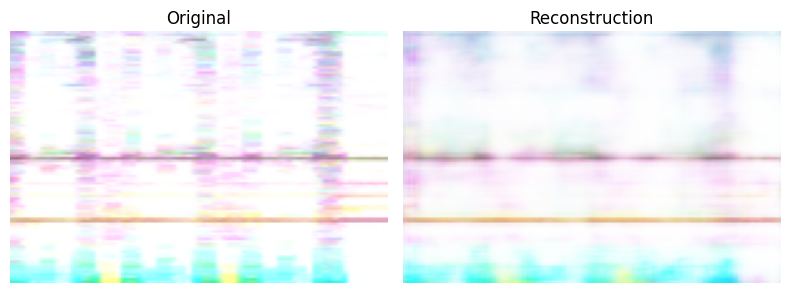

In [28]:
# -----------------------------
# Sample selection
# -----------------------------
idx = 31  # choose any index in the validation set
sample = x_val[idx]
sample_input = np.expand_dims(sample, axis=0)  # shape: (1, H, W, C)

# -----------------------------
# Reconstruction
# -----------------------------
recon = autoencoder.predict(sample_input, verbose=0)[0]

# -----------------------------
# Reconstruction Error (MSE)
# -----------------------------
mse = np.mean((sample - recon) ** 2)
print(f"Reconstruction MSE: {mse:.6f}")

label = y_val[idx]
print("Label:", "GOOD" if label == 0 else "BAD")

# -----------------------------
# Visualization: original vs reconstruction
# -----------------------------
fig, axs = plt.subplots(1, 2, figsize=(8, 4))

axs[0].imshow(sample)
axs[0].set_title("Original")
axs[0].axis("off")

axs[1].imshow(recon)
axs[1].set_title("Reconstruction")
axs[1].axis("off")

plt.tight_layout()
plt.show()

## Saving the Trained Model

To enable reuse and reproducibility, we save the trained autoencoder to disk.  
The saved model can later be loaded for evaluation on anomalous data or for inference in other scripts.

In [ ]:
MODEL_DIR = Path("../../models")
MODEL_DIR.mkdir(parents=True, exist_ok=True)
model_path = MODEL_DIR / "ae_bn16_bosch_dataset_M01_OP12_20260624.keras"

# -----------------------------
# Save the trained model
# -----------------------------
autoencoder.save(model_path)

print(f"Model saved to: {model_path}")

Model saved to: ..\models\ae_bn16_bosch_dataset_M01_OP10_20260624.keras


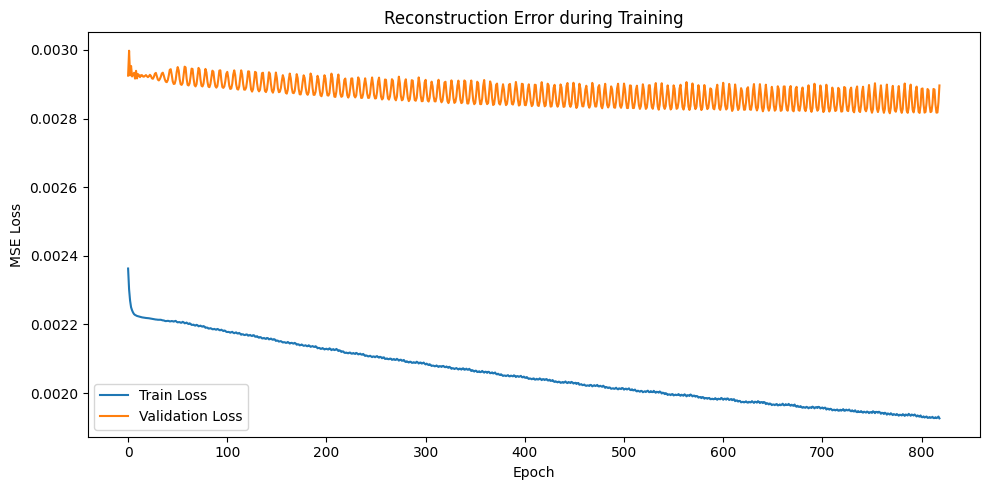

In [29]:
plt.figure(figsize=(10, 5))

plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.title('Reconstruction Error during Training')
plt.legend()
plt.tight_layout()
plt.show()

In [30]:
print("Final Train Loss:", history.history['loss'][-1])
print("Final Val Loss:", history.history['val_loss'][-1])

Final Train Loss: 0.0019264797447249293
Final Val Loss: 0.002896297723054886


# Reconstruction & Validation 

In [31]:
recon_val = autoencoder.predict(x_val, batch_size=32, verbose=1)

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step 


In [32]:
val_errors = np.mean((x_val - recon_val)**2, axis=(1, 2, 3))
file_ids_val = [extract_file_id(p) for p in val_paths]

In [33]:
df_val = pd.DataFrame({
    "file_id": file_ids_val,
    "error": val_errors,
    "label": y_val
})

In [34]:
file_scores_val = []

for file_id, group in df_val.groupby("file_id"):

    label = group["label"].iloc[0]   # ✅ korrekt (File-Level Label)
    errors = group["error"].values

    score = np.max(errors)   # 🔥 wichtig!

    file_scores_val.append({
        "file_id": file_id,
        "label": label,
        "score": score
    })

file_val = pd.DataFrame(file_scores_val)

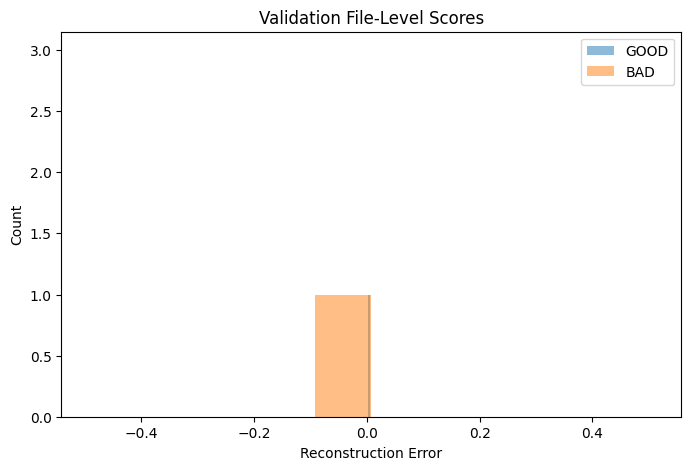

In [35]:
good_scores = file_val[file_val["label"] == 0]["score"]
bad_scores = file_val[file_val["label"] == 1]["score"]

plt.figure(figsize=(8,5))

plt.hist(good_scores, bins=10, alpha=0.5, label="GOOD")
plt.hist(bad_scores, bins=10, alpha=0.5, label="BAD")

plt.legend()
plt.title("Validation File-Level Scores")
plt.xlabel("Reconstruction Error")
plt.ylabel("Count")

plt.show()


In [36]:
from sklearn.metrics import precision_recall_curve

precision, recall, thresholds = precision_recall_curve(
    file_val["label"],
    file_val["score"]
)

f1 = 2 * precision[:-1] * recall[:-1] / (precision[:-1] + recall[:-1] + 1e-12)

best_idx = np.argmax(f1)
best_threshold = thresholds[best_idx]

print("Best threshold:", best_threshold)


Best threshold: 0.007828671


### Reconstruction on Test Set

In [37]:
recon_test = autoencoder.predict(x_test, batch_size=32, verbose=1)
test_errors = np.mean((x_test - recon_test)**2, axis=(1, 2, 3))


file_ids_test = [extract_file_id(p) for p in test_paths]

df_test = pd.DataFrame({
    "file_id": file_ids_test,
    "error": test_errors,
    "label": y_test
})


file_scores_test = []

for file_id, group in df_test.groupby("file_id"):

    label = group["label"].iloc[0]
    errors = group["error"].values

    score = np.max(errors)

    file_scores_test.append({
        "file_id": file_id,
        "label": label,
        "score": score
    })

file_test = pd.DataFrame(file_scores_test)



3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step


In [38]:
from sklearn.metrics import roc_auc_score, average_precision_score

roc_auc = roc_auc_score(file_test["label"], file_test["score"])
pr_auc = average_precision_score(file_test["label"], file_test["score"])

print("ROC-AUC:", roc_auc)
print("PR-AUC:", pr_auc)


ROC-AUC: 1.0
PR-AUC: 1.0


In [39]:
from sklearn.metrics import classification_report, confusion_matrix

y_pred = (file_test["score"] >= best_threshold).astype(int)

print(classification_report(file_test["label"], y_pred))
print(confusion_matrix(file_test["label"], y_pred))


              precision    recall  f1-score   support

           0       0.88      1.00      0.93         7
           1       0.00      0.00      0.00         1

    accuracy                           0.88         8
   macro avg       0.44      0.50      0.47         8
weighted avg       0.77      0.88      0.82         8

[[7 0]
 [1 0]]


c:\Users\Zeleny\Documents\01_VSCode\spectrogram-anomaly-ae\.spectro-ae-venv\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Zeleny\Documents\01_VSCode\spectrogram-anomaly-ae\.spectro-ae-venv\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Zeleny\Documents\01_VSCode\spectrogram-anomaly-ae\.spectro-ae-venv\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zer

In [40]:
def load_segments_from_file_id(file_id, file_to_paths):
    paths = sorted(file_to_paths[file_id])

    segments = []
    for p in paths:
        img = np.array(Image.open(p).convert("RGB")) / 255.0
        segments.append(img)

    return np.array(segments), paths


def plot_segments(original, recon, diff, errors, title="", max_cols=5):
    n = len(original)

    cols = max_cols
    rows = int(np.ceil(n / cols))

    fig, axes = plt.subplots(rows * 3, cols, figsize=(15, rows * 6))

    # Falls nur 1 Zeile → axes 2D machen
    axes = np.array(axes).reshape(rows * 3, cols)

    for i in range(n):
        r = i // cols
        c = i % cols

        # Original
        axes[r*3 + 0, c].imshow(original[i])
        axes[r*3 + 0, c].set_title(f"Orig {i}")
        axes[r*3 + 0, c].axis("off")

        # Rekonstruktion
        axes[r*3 + 1, c].imshow(recon[i])
        axes[r*3 + 1, c].set_title("Recon")
        axes[r*3 + 1, c].axis("off")

        # Differenz
        axes[r*3 + 2, c].imshow(diff[i], cmap="inferno")
        axes[r*3 + 2, c].set_title(f"MSE={errors[i]:.4f}")
        axes[r*3 + 2, c].axis("off")

    # leere Felder aus
    for j in range(n, rows * cols):
        for k in range(3):
            axes[(j // cols)*3 + k, j % cols].axis("off")

    plt.suptitle(title, fontsize=16)
    plt.tight_layout()
    plt.show()

def reconstruct_segments_tf(model, segments):
    """
    segments: numpy array (N, H, W, 3)
    """
    # Vorhersage
    recon = model.predict(segments, verbose=0)

    # Differenzbild (pixelweise)
    diff = np.abs(segments - recon)

    # MSE pro Segment
    errors = np.mean((segments - recon) ** 2, axis=(1, 2, 3))

    return recon, diff, errors


In [41]:
# z.B. erstes File aus Test-Set
good_id = test_files[0]

segments_good, paths_good = load_segments_from_file_id(good_id, file_to_paths)

print("GOOD segments shape:", segments_good.shape)


bad_id = bad_test_files[0]

segments_bad, paths_bad = load_segments_from_file_id(bad_id, bad_file_to_paths)

print("BAD segments shape:", segments_bad.shape)


GOOD segments shape: (9, 100, 150, 3)
BAD segments shape: (8, 100, 150, 3)


GOOD mean: 0.002401646221782667 max: 0.0031873973113270954


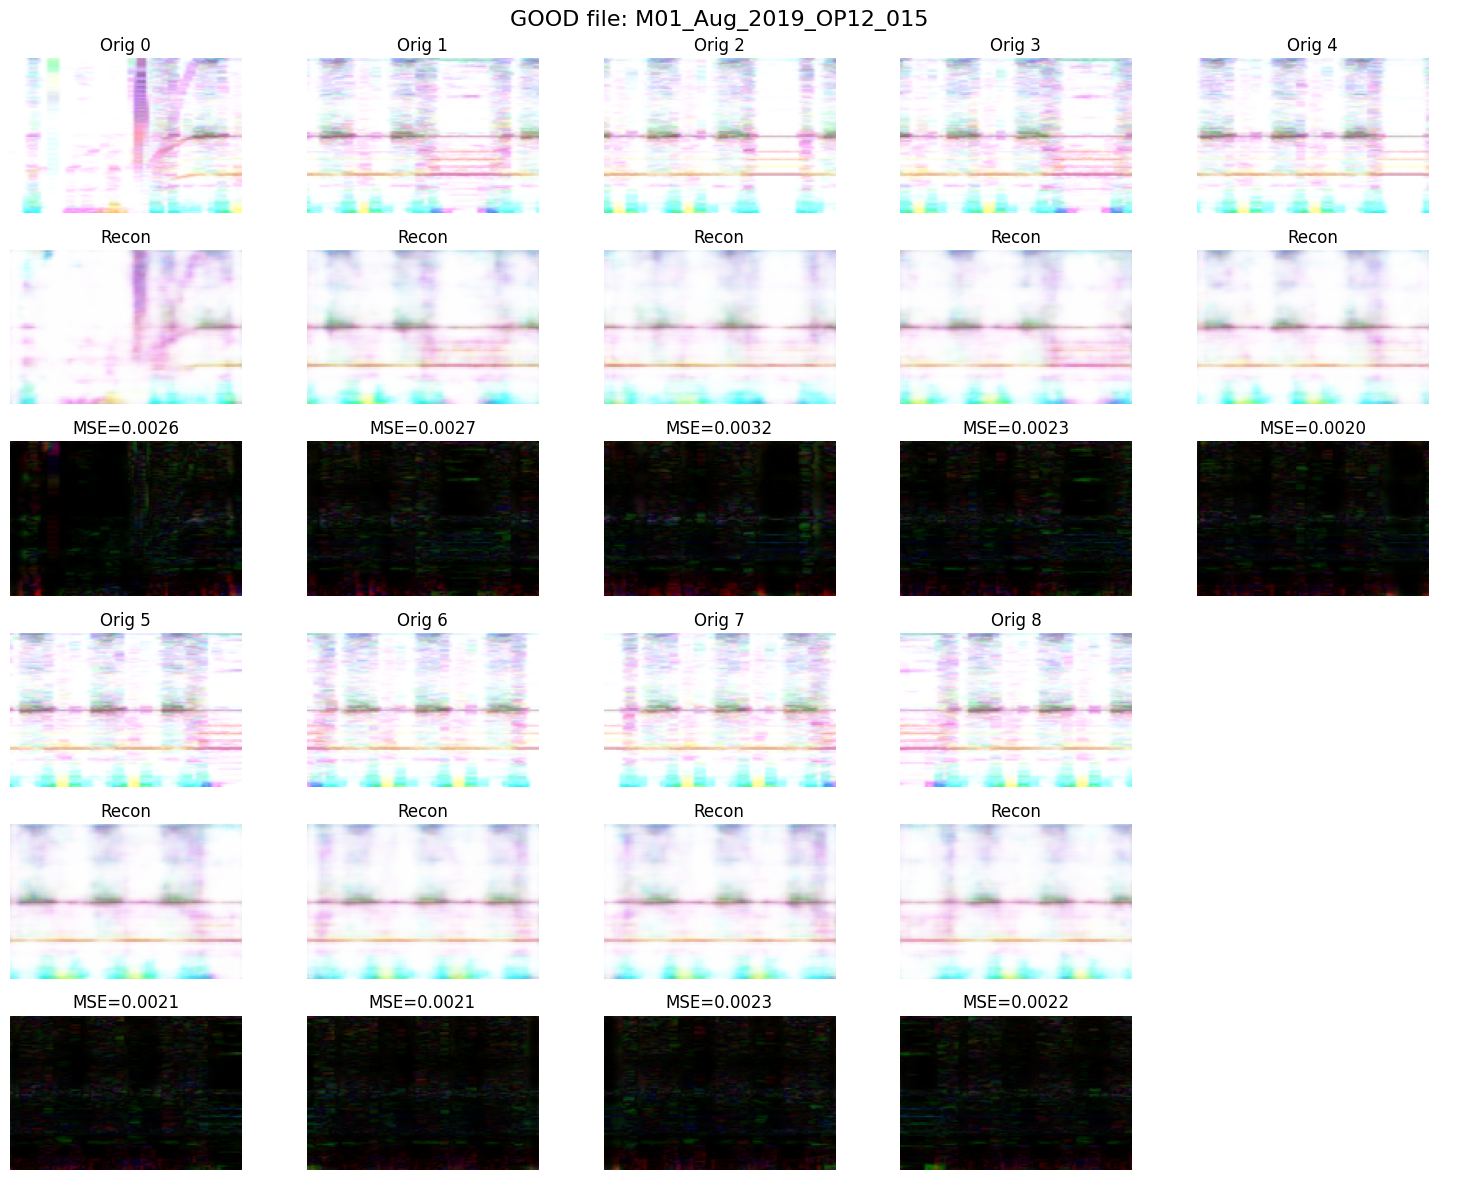

In [42]:

recon_good, diff_good, err_good = reconstruct_segments_tf(autoencoder, segments_good)

print("GOOD mean:", err_good.mean(), "max:", err_good.max())

plot_segments(
    segments_good,
    recon_good,
    diff_good,
    err_good,
    title=f"GOOD file: {good_id}"
)



BAD mean: 0.005241108849621438 max: 0.006252243974599802


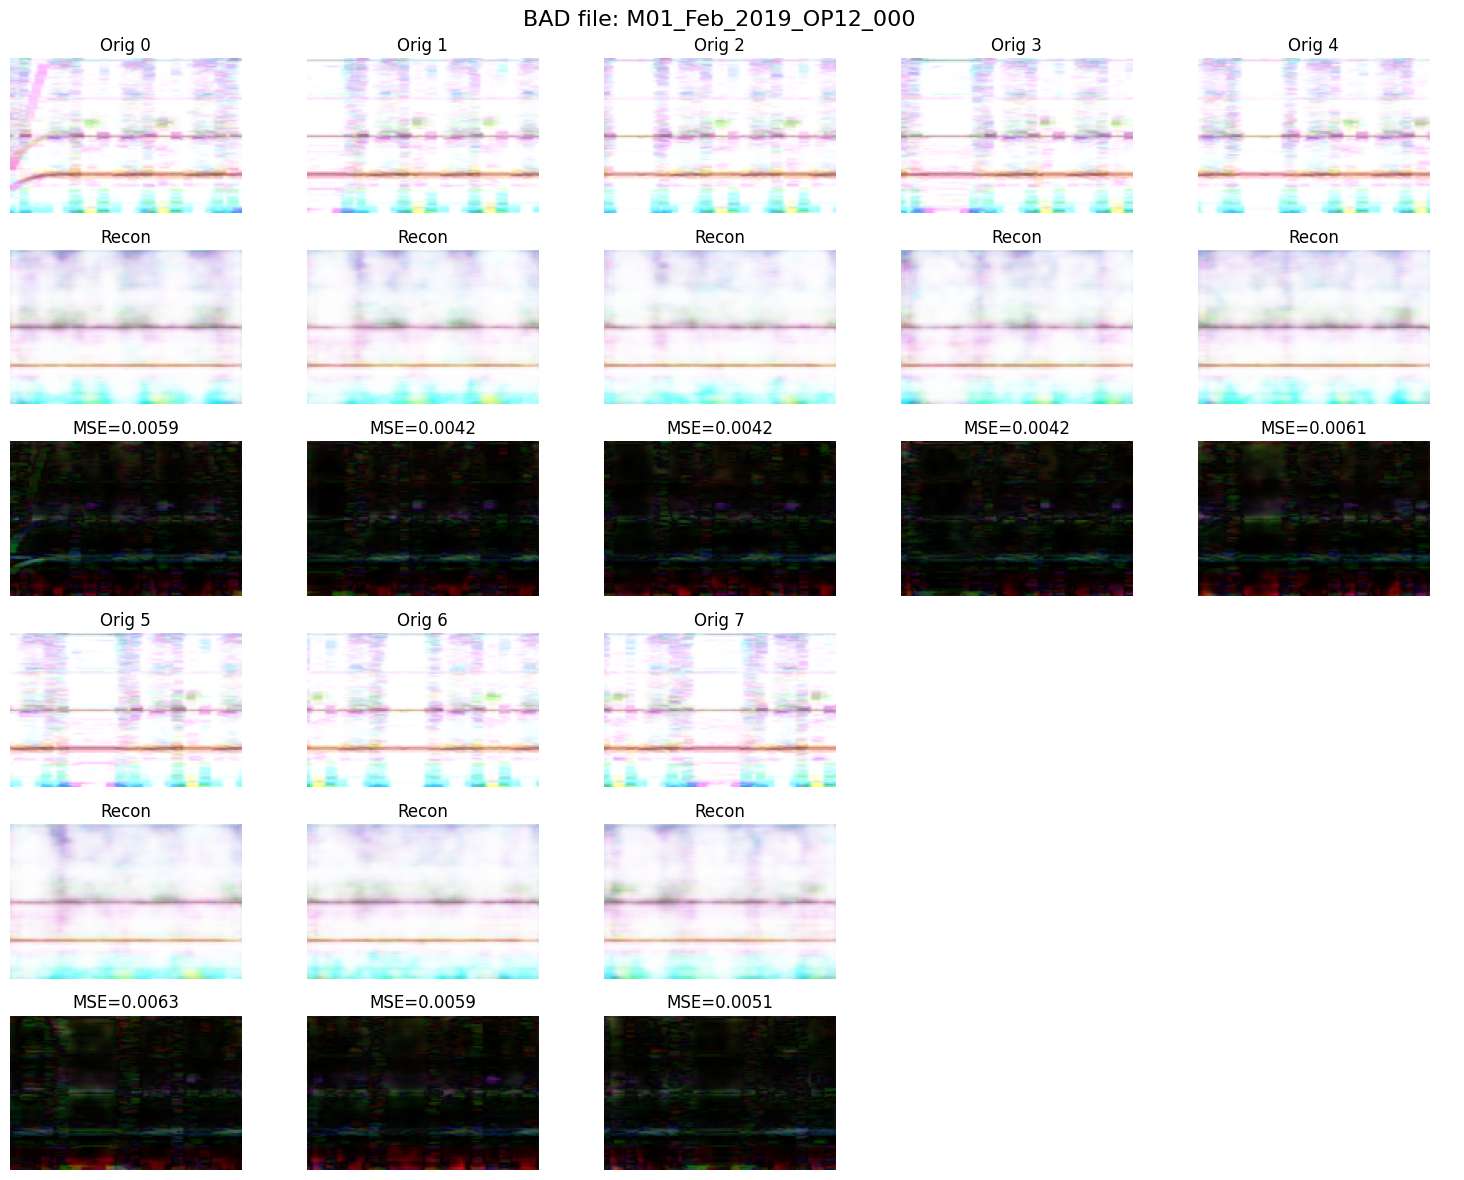

In [43]:

recon_bad, diff_bad, err_bad = reconstruct_segments_tf(autoencoder, segments_bad)

print("BAD mean:", err_bad.mean(), "max:", err_bad.max())

plot_segments(
    segments_bad,
    recon_bad,
    diff_bad,
    err_bad,
    title=f"BAD file: {bad_id}"
)
